# Sandhill Crane annotation demo

A small, self-contained walk through the basic bioacoustic annotation workflow:
load a recording, view it as a spectrogram, detect call **onsets and offsets**,
assign a frequency band to each event, and export a **Raven-compatible selection table**.

*This is textbook methodology on open audio, published as a public companion to
the private GRUS research pipeline.*

## Audio sources

The notebook tries three sources, in order:

1. **Your own file.** Set `AUDIO_PATH` below to any local recording. This is the
   normal way to use it.
2. **xeno-canto.** As of October 2025 the xeno-canto API (v3) requires a free API
   key. Register at [xeno-canto.org](https://xeno-canto.org), then set the
   environment variable `XC_API_KEY` before launching Jupyter. No audio is
   redistributed in this repo; recordings are fetched at runtime and remain under
   the recordist's Creative Commons license.
3. **Synthesized fallback.** If neither is available, the notebook generates a
   crane-like test signal so every cell still runs end to end. Useful for CI and
   for reading the notebook without any setup.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
warnings.filterwarnings("ignore")

SR = 22050          # analysis sample rate
MAX_SECONDS = 60    # cap so the demo stays quick
AUDIO_PATH = None   # <- set to a local file path to use your own recording

## 1. Get a recording

In [2]:
def load_local(path):
    y, _ = librosa.load(path, sr=SR, mono=True, duration=MAX_SECONDS)
    print(f"loaded local file: {path}")
    return y, os.path.splitext(os.path.basename(path))[0]


def load_xeno_canto():
    """xeno-canto API v3. Requires a free API key (mandatory since 2025-10-10)."""
    import requests
    key = os.environ.get("XC_API_KEY")
    if not key:
        raise RuntimeError("XC_API_KEY not set")
    r = requests.get(
        "https://xeno-canto.org/api/3/recordings",
        params={"query": 'sp:"Antigone canadensis" q:A', "key": key},
        timeout=30,
    )
    r.raise_for_status()
    recs = r.json().get("recordings", [])
    if not recs:
        raise RuntimeError("no recordings returned")
    rec = recs[0]
    audio = requests.get(rec["file"], params={"key": key}, timeout=90)
    audio.raise_for_status()
    tmp = "crane_source.mp3"
    with open(tmp, "wb") as f:
        f.write(audio.content)
    y, _ = librosa.load(tmp, sr=SR, mono=True, duration=MAX_SECONDS)
    print(f"xeno-canto XC{rec['id']} | recordist: {rec['rec']} | license: {rec['lic']}")
    print("Audio remains under the recordist's Creative Commons license.")
    return y, f"XC{rec['id']}"


def synth_fallback(dur=20.0):
    """Crane-like test signal: repeated FM 'rattle' bursts with harmonics over noise."""
    rng = np.random.default_rng(7)
    n_total = int(SR * dur)
    y = 0.004 * rng.standard_normal(n_total)
    starts = np.cumsum(rng.uniform(1.0, 2.4, size=12))
    for s in starts[starts < dur - 1.2]:
        n = int(SR * rng.uniform(0.35, 0.75))
        tt = np.arange(n) / SR
        f0 = rng.uniform(550, 750)
        sweep = f0 * (1 + 0.25 * np.sin(2 * np.pi * 22 * tt))
        phase = 2 * np.pi * np.cumsum(sweep) / SR
        burst = 0.6 * np.sin(phase) + 0.35 * np.sin(2 * phase) + 0.18 * np.sin(3 * phase)
        i0 = int(s * SR)
        y[i0:i0 + n] += burst * np.hanning(n) * rng.uniform(0.55, 0.9)
    print("using synthesized crane-like test signal (no local file, no XC_API_KEY)")
    return y.astype(np.float32), "SYNTH"


y = source_id = None
if AUDIO_PATH:
    y, source_id = load_local(AUDIO_PATH)
else:
    try:
        y, source_id = load_xeno_canto()
    except Exception as e:
        print(f"xeno-canto unavailable ({type(e).__name__}: {e}); falling back.")
        y, source_id = synth_fallback()

print(f"{len(y)/SR:.1f} s at {SR} Hz")

xeno-canto unavailable (RuntimeError: XC_API_KEY not set); falling back.
using synthesized crane-like test signal (no local file, no XC_API_KEY)
20.0 s at 22050 Hz


## 2. Look at it: waveform and spectrogram

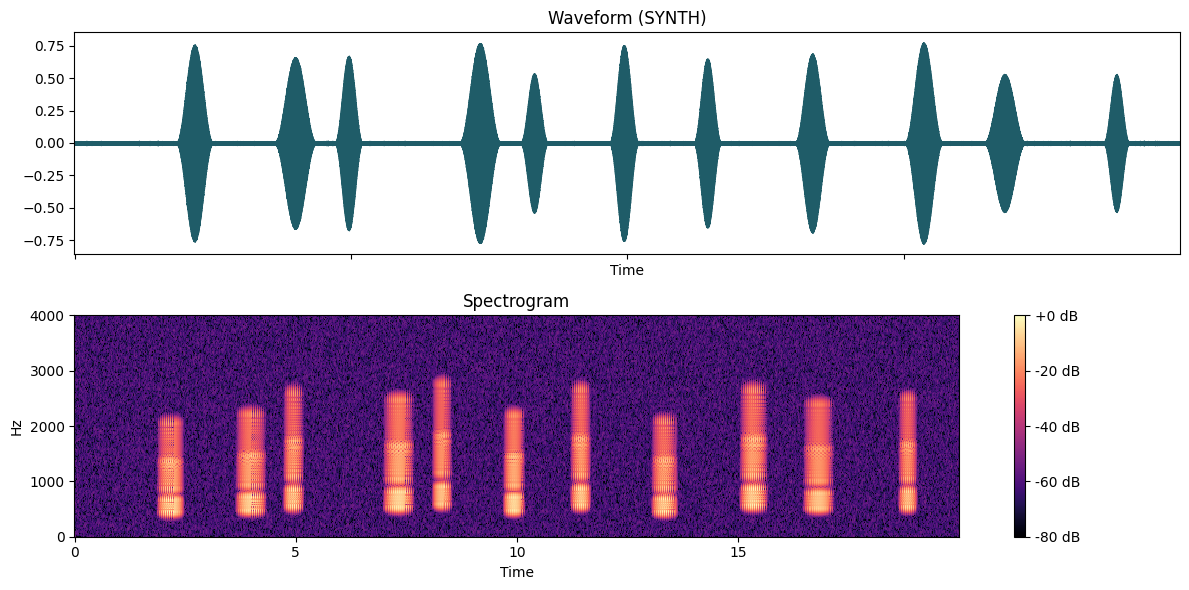

In [3]:
HOP, NFFT = 256, 1024
S = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=NFFT, hop_length=HOP)), ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
librosa.display.waveshow(y, sr=SR, ax=axes[0], color="#1F5C68")
axes[0].set_title(f"Waveform ({source_id})")
img = librosa.display.specshow(S, sr=SR, hop_length=HOP, x_axis="time",
                               y_axis="hz", ax=axes[1], cmap="magma")
axes[1].set_ylim(0, 4000)
axes[1].set_title("Spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout(); plt.savefig("fig_spectrogram.png", dpi=110); plt.show()

## 3. Detect onsets, estimate offsets

Onsets come from `librosa.onset.onset_detect` with backtracking to the local
energy minimum. Offsets use a simple, inspectable rule: within the window
between this onset and the next one, find the energy peak, then walk forward
along the RMS envelope until it decays below a fraction of that peak.

Bounding each event by the **next onset** matters. Without it, a loud call
arriving shortly after a quiet one captures the peak search and swallows both
into a single oversized selection.

Simple and transparent is the point: this is an annotation *assist*, and every
boundary should be easy to hand-correct in Raven afterwards.

In [4]:
rms = librosa.feature.rms(y=y, frame_length=NFFT, hop_length=HOP)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=SR, hop_length=HOP)
noise_floor = np.percentile(rms, 20)

onsets = librosa.onset.onset_detect(y=y, sr=SR, hop_length=HOP,
                                    backtrack=True, units="frames")

MAX_EVENT_FRAMES = int(3.0 * SR / HOP)   # no single call runs longer than 3 s
DECAY_FRAC       = 0.15                  # offset when envelope falls below 15% of peak
MIN_SNR          = 3.0                   # peak must clear 3x the noise floor

events = []
for i, f in enumerate(onsets):
    # Bound the search at the next onset so neighbouring calls stay separate.
    nxt = onsets[i + 1] if i + 1 < len(onsets) else len(rms)
    stop = min(f + MAX_EVENT_FRAMES, nxt, len(rms))
    win = rms[f:stop]
    if win.size == 0:
        continue

    peak = win.max()
    if peak < MIN_SNR * noise_floor:
        continue  # too weak to call an event

    g = f + int(np.argmax(win))                       # frame of the peak
    thresh = max(DECAY_FRAC * peak, 1.5 * noise_floor)
    end = g
    while end < stop - 1 and rms[end] > thresh:
        end += 1

    t0, t1 = float(times[f]), float(times[end])
    if t1 - t0 >= 0.05:
        events.append([t0, t1])

# Merge anything that still overlaps after bounding.
merged = []
for t0, t1 in sorted(events):
    if merged and t0 <= merged[-1][1] + 0.02:
        merged[-1][1] = max(merged[-1][1], t1)
    else:
        merged.append([t0, t1])

durs = [t1 - t0 for t0, t1 in merged]
print(f"{len(merged)} events | duration min {min(durs):.2f}s "
      f"median {np.median(durs):.2f}s max {max(durs):.2f}s")

11 events | duration min 0.41s median 0.53s max 0.64s


## 4. Assign a frequency band per event

For each event we take the band-limited spectrum and keep the range holding the
central 90% of energy between 200 Hz and 4 kHz, a reasonable envelope for
Sandhill Crane calls.

In [5]:
Smag = np.abs(librosa.stft(y, n_fft=NFFT, hop_length=HOP))
freqs = librosa.fft_frequencies(sr=SR, n_fft=NFFT)
band = (freqs >= 200) & (freqs <= 4000)
band_freqs = freqs[band]

rows = []
for i, (t0, t1) in enumerate(merged, start=1):
    f0, f1 = librosa.time_to_frames([t0, t1], sr=SR, hop_length=HOP)
    spec = Smag[band, f0:max(f1, f0 + 1)].sum(axis=1)
    if spec.sum() <= 0:
        lo, hi = 200.0, 4000.0
    else:
        c = np.cumsum(spec) / spec.sum()
        lo = float(band_freqs[np.searchsorted(c, 0.05)])
        hi = float(band_freqs[min(np.searchsorted(c, 0.95), len(band_freqs) - 1)])
    rows.append({"Selection": i, "View": "Spectrogram 1", "Channel": 1,
                 "Begin Time (s)": round(t0, 4), "End Time (s)": round(t1, 4),
                 "Low Freq (Hz)": round(lo, 1), "High Freq (Hz)": round(hi, 1)})

sel = pd.DataFrame(rows)
sel.head(10)

,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz)
0,1,Spectrogram 1,1,1.8228,2.4149,430.7,1981.1
1,2,Spectrogram 1,1,3.6455,4.2725,452.2,2131.8
2,3,Spectrogram 1,1,4.7253,5.1432,538.3,2476.3
3,4,Spectrogram 1,1,6.9892,7.6161,516.8,2368.7
4,5,Spectrogram 1,1,8.0922,8.4985,581.4,2627.1
5,6,Spectrogram 1,1,9.6827,10.1355,452.2,2110.3
6,7,Spectrogram 1,1,11.2152,11.6332,559.9,2540.9
7,8,Spectrogram 1,1,13.0496,13.5837,430.7,2024.1
8,9,Spectrogram 1,1,15.0233,15.6154,559.9,2519.4
9,10,Spectrogram 1,1,16.4629,17.1015,495.3,2304.1


## 5. Export a Raven selection table

Raven and Raven Lite open tab-separated selection tables directly
(`File > Open Selection Table` with the audio loaded). This is the handoff point
between automated assistance and expert human review.

In [6]:
out = f"selections_{source_id}.txt"
sel.to_csv(out, sep="\t", index=False)
print(f"wrote {out} with {len(sel)} selections")
print(open(out).read()[:400])

wrote selections_SYNTH.txt with 11 selections
Selection	View	Channel	Begin Time (s)	End Time (s)	Low Freq (Hz)	High Freq (Hz)
1	Spectrogram 1	1	1.8228	2.4149	430.7	1981.1
2	Spectrogram 1	1	3.6455	4.2725	452.2	2131.8
3	Spectrogram 1	1	4.7253	5.1432	538.3	2476.3
4	Spectrogram 1	1	6.9892	7.6161	516.8	2368.7
5	Spectrogram 1	1	8.0922	8.4985	581.4	2627.1
6	Spectrogram 1	1	9.6827	10.1355	452.2	2110.3
7	Spectrogram 1	1	11.2152	11.6332	559.9	2540.9
8	


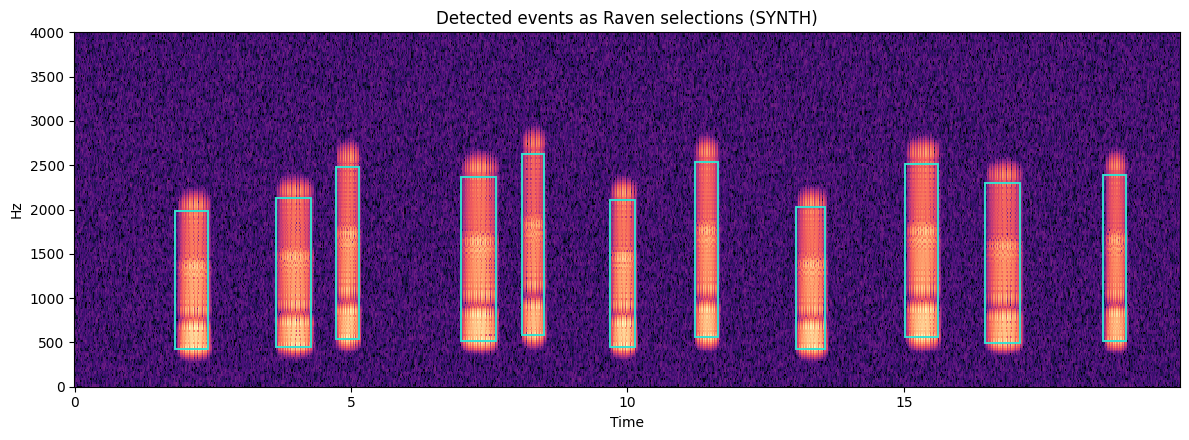

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
img = librosa.display.specshow(S, sr=SR, hop_length=HOP, x_axis="time",
                               y_axis="hz", ax=ax, cmap="magma")
ax.set_ylim(0, 4000)
for _, r in sel.iterrows():
    ax.add_patch(plt.Rectangle(
        (r["Begin Time (s)"], r["Low Freq (Hz)"]),
        r["End Time (s)"] - r["Begin Time (s)"],
        r["High Freq (Hz)"] - r["Low Freq (Hz)"],
        fill=False, edgecolor="#35E0D0", linewidth=1.4))
ax.set_title(f"Detected events as Raven selections ({source_id})")
plt.tight_layout(); plt.savefig("fig_selections.png", dpi=110); plt.show()

## What this demo is not

This is deliberately the *simple* version: energy-based detection, transparent
thresholds, no learned models, no call-type classification. Production
annotation work (multi-observer protocols, call-type taxonomies, sequence
analysis) lives in the private GRUS pipeline pending publication.

The demo's job is to show the shape of the workflow and produce artifacts a
reviewer can open in Raven and check by ear.